# Análisis Exploratorio de Datos

**Caso de Estudio:** Spotify Tracks Dataset  
**Asignatura:** MLY1101 — Machine Learning  
**Evaluación Parcial N°1**  
**Por:** Felipe Ahumada Silva y Francisca Carrasco Lozano

---

## Descripción

Este notebook corresponde a la **Fase 2 (Comprensión de los datos)** de la metodología CRISP-DM
aplicada al caso de estudio Spotify Tracks Dataset. Se realiza el análisis exploratorio del dataset, que contiene información de más de 100.000 pistas junto
a sus características de audio (danceability, energy, loudness, tempo, entre otras)
y metadatos (artista, álbum, género). El objetivo de negocio es comprender qué
atributos se relacionan con la popularidad de una canción, como insumo para futuras
tareas de modelado predictivo.

Mantiene el uso de pipeline como buena práctica de la industria.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. Bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (>=3.7.1)
- numpy (>=2.0.0)
- seaborn (>=0.12.0)

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

# Importación de librerías

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('bmh')

os.makedirs('../images', exist_ok=True)

# Carga de Datos

In [2]:
df1 = pd.read_csv('../data/Spotify_Tracks_Dataset.csv' ,index_col=0)
df1.sample(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
73841,7aTsbBoGoSNy0r8yXncVFR,Paul Kalkbrenner,Superimpose,Far Away,18,366266,False,0.792,0.419,1,-16.239,1,0.2510,0.0134,0.873,0.1120,0.423,135.982,4,minimal-techno
31380,0nrWZWkJM62ftQJSI8fDc0,Alan Walker;Sophia Somajo,Different World,Diamond Heart,63,240333,False,0.478,0.633,0,-6.190,1,0.0345,0.1230,0.000,0.4100,0.287,89.909,4,electro
25973,7wzwYGQ4JQWYjJ30IjTeth,Tavares,Anthology,Check It Out - Remastered,30,206933,False,0.415,0.358,7,-13.509,1,0.0382,0.7590,0.000,0.6700,0.422,125.414,4,disco
4920,03fImIJ7r7he62QmwI1Tyv,Yann Tiersen,The Lighthouse,The Drowned Girl - Edit,51,123000,False,0.525,0.209,7,-9.403,1,0.0442,0.8280,0.927,0.0712,0.944,138.702,3,ambient
84732,1raiIrqaqRAqZmQWZlLuBd,The Beatles,1 (Remastered),Lady Madonna - Remastered 2015,58,136826,False,0.650,0.777,2,-4.984,1,0.0294,0.1410,0.343,0.2150,0.574,109.608,4,psych-rock


# Información básica

> Para la descripción detallada de los datos, por favor revisa el documento [`spotify_dataset.pdf`](../docs/spotify_dataset.pdf).

## ¿Cuantas columnas y filas contiene el dataset?

In [3]:
filas, columnas = df1.shape
print(f'Filas = {filas}\nColumnas = {columnas}')

Filas = 114000
Columnas = 20


## ¿Existen filas duplicadas?

In [4]:
# Duplicados exactos: filas idénticas en todas las columnas
duplicados_exactos = df1.duplicated().sum()
print(f'Filas totalmente duplicadas: {duplicados_exactos}')

# Duplicados por track_id: la misma canción puede repetirse (ej. en distintos géneros)
duplicados_track_id = df1.duplicated(subset='track_id').sum()
print(f'Canciones repetidas (mismo track_id): {duplicados_track_id}')

Filas totalmente duplicadas: 450
Canciones repetidas (mismo track_id): 24259


In [5]:
# Se busca un patrón con respecto a los track_id
cols = ['track_id', 'track_name', 'artists', 'track_genre', 'popularity']
duplicados_vista = (
    df1[df1.duplicated(subset='track_id', keep=False)]
    .sort_values('track_id')[cols]
    .head(20)
)

duplicados_vista

,track_id,track_name,artists,track_genre,popularity
15028,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,chill,0
103211,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,soul,0
85578,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,punk-rock,38
100420,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,ska,38
91801,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,rock,86
3257,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alternative,86
2106,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alt-rock,86
33178,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,emo,58
94239,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,sad,58
97533,006rHBBNLJMpQs8fRC2GDe,Agora Estou Sofrendo - Ao Vivo,Calcinha Preta;Gusttavo Lima,sertanejo,47


## Consolidación de canciones repetidas por género

Se confirmó que las filas repetidas por track_id corresponden a la misma canción: mismo track_name, artists y valores de audio (danceability, energy, loudness, etc.) idénticos, solo publicada bajo distintos géneros.  

Para dejar una única fila por canción se aplica lo siguiente:

- **track_genre**: se unen todos los géneros de cada canción separados por ;, con el mismo criterio que ya usa la columna artists para más de un artista.
- **popularity**: variaba levemente entre géneros en un 4.33% de los casos, por lo que se promedia y se redondea a entero.
- El resto de las columnas es idéntico dentro de cada track_id, por lo que se conserva el primer valor de cada grupo.

Con esto el dataset pasó de 114.000 filas a 89.741 filas, una por canción única.

In [6]:
filas_antes = len(df1)

agregaciones = {col: 'first' for col in df1.columns if col not in ['track_id', 'track_genre', 'popularity']}
agregaciones['track_genre'] = lambda generos: ';'.join(sorted(set(generos)))
agregaciones['popularity'] = 'mean'

df2 = df1.groupby('track_id', as_index=False).agg(agregaciones)
df2['popularity'] = df2['popularity'].round().astype(int)

print(f'Filas antes de consolidar: {filas_antes}')
print(f'Filas después de consolidar: {len(df2)}')
df2.sample(5)

Filas antes de consolidar: 114000
Filas después de consolidar: 89741


,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
13223,191Tg9ZpGyjqP5sLO5gg3V,Emma Shapplin,Etterna,Leonora,237240,False,0.295,0.525,9,-8.716,1,0.0425,0.36000,0.000102,0.164,0.136,69.014,4,opera,21
63157,5UZA39t4lX42ApegVubl7f,Martin Garrix;Matisse & Sadko;John Martin,Won’t Let You Go,Won’t Let You Go,217261,False,0.460,0.843,2,-5.164,0,0.0616,0.00623,0.000000,0.160,0.276,125.982,4,progressive-house,57
28750,2VBluJiNj9bKohWX0dY1Lh,Paramore,Paramore,Last Hope,309973,False,0.465,0.711,5,-6.178,1,0.0265,0.00411,0.000548,0.164,0.255,101.460,4,emo,63
42253,3fHPPqfiXlGM5ZauZpAa2r,Willie Gonzalez,Lo Nuevo Y Lo Mejor (En Vivo),Seda - En Vivo,313573,False,0.463,0.782,0,-7.841,1,0.0395,0.12700,0.000028,0.348,0.536,168.275,4,salsa,27
63722,5XnR9Qr45IYgJMAwHl0ea8,Sex Prisoner,Sex Prisoner,Kept in a Position of Power,92740,False,0.257,0.968,7,-5.979,1,0.1020,0.00183,0.286000,0.212,0.163,76.969,4,grindcore,12


In [7]:
duplicados_exactos = df2.duplicated().sum()
print(f'Filas totalmente duplicadas: {duplicados_exactos}')

Filas totalmente duplicadas: 0


Al unificar los géneros, como efecto colateral ya no existen duplicados exactos (misma fila repetida en todas las columnas). Sí queda, como se ve a continuación, audio idéntico bajo track_id distintos, un tipo de duplicado que esta consolidación no puede resolver, porque agrupa por track_id, no por contenido.

La consolidación anterior resuelve los duplicados que comparten track_id, pero
track_id identifica un *release* (álbum, single, recopilatorio), no la canción
en sí. Cabe preguntarse si queda audio idéntico bajo track_id distintos —
por ejemplo, una canción reeditada o incluida en un álbum recopilatorio.

In [8]:
audio_cols = ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
              'speechiness', 'acousticness', 'instrumentalness', 'liveness',
              'valence', 'tempo', 'time_signature']

audio_duplicado = df2.duplicated(subset=audio_cols, keep=False)
n_filas = audio_duplicado.sum()

print(f'Filas con audio idéntico bajo track_id distinto: {n_filas} ({n_filas/len(df2)*100:.2f}%)')
print(f'Grupos de audio distintos involucrados: {df2[audio_duplicado].groupby(audio_cols).ngroups}')

Filas con audio idéntico bajo track_id distinto: 9284 (10.35%)
Grupos de audio distintos involucrados: 3022


Sí existen, y en un volumen no despreciable (~10% de df2): la consolidación por
track_id fue necesaria pero no suficiente, resolvió el duplicado por género,
no el duplicado por reedición/relanzamiento. Como cada release tiene su propia
popularity, esto deja pares de filas con features de audio prácticamente
indistinguibles pero etiquetas de salida distintas.

In [9]:
rango_popularidad = (
    df2[audio_duplicado]
    .groupby(audio_cols)['popularity']
    .agg(lambda s: s.max() - s.min())
)

print(f'Grupos con rango de popularity >= 30 puntos: {(rango_popularidad >= 30).sum()}')

grupo_extremo = rango_popularidad.idxmax()
(
    df2[audio_duplicado]
    .set_index(audio_cols)
    .loc[[grupo_extremo], ['track_name', 'artists', 'album_name', 'popularity']]
)

Grupos con rango de popularity >= 30 puntos: 466


track_name  \
duration_ms danceability energy key loudness mode speechiness acousticness instrumentalness liveness valence tempo  time_signature                    
175238      0.561        0.965  7   -3.673   0    0.0343      0.00383      0.000007         0.371    0.304   128.04 4               I'm Good (Blue)   
                                                                                                                    4               I'm Good (Blue)   
                                                                                                                    4               I'm Good (Blue)   
                                                                                                                    4               I'm Good (Blue)   
                                                                                                                    4               I'm Good (Blue)   
                                                                                                                    4               I'm Good (Blue)   

                                                                                                                                                    artists  \
duration_ms danceability energy key loudness mode speechiness acousticness instrumentalness liveness valence tempo  time_signature                            
175238      0.561        0.965  7   -3.673   0    0.0343      0.00383      0.000007         0.371    0.304   128.04 4               David Guetta;Bebe Rexha   
                                                                                                                    4               David Guetta;Bebe Rexha   
                                                                                                                    4               David Guetta;Bebe Rexha   
                                                                                                                    4               David Guetta;Bebe Rexha   
                                                                                                                    4               David Guetta;Bebe Rexha   
                                                                                                                    4               David Guetta;Bebe Rexha   

                                                                                                                                                    album_name  \
duration_ms danceability energy key loudness mode speechiness acousticness instrumentalness liveness valence tempo  time_signature                               
175238      0.561        0.965  7   -3.673   0    0.0343      0.00383      0.000007         0.371    0.304   128.04 4                         New Pop Classics   
                                                                                                                    4                      Baddest of Them All   
                                                                                                                    4               From The Ashes - New Beats   
                                                                                                                    4                               Upbeat Pop   
                                                                                                                    4                          I'm Good (Blue)   
                                                                                                                    4                  I'm Blue - Hits of 2022   

                                                                                                                                    popularity  
duration_ms danceability energy key loudness mode speechiness acousticness instrumentalness liveness valence tempo  time_signature              
175238      0.561        0.965  7   -3.673   0    0.0343      0.0038

El caso más extremo es una misma canción con popularity 0 en un release y 98
en otro, la diferencia no viene del audio (es idéntico), sino del contexto de
publicación (álbum, momento, promoción). Esto no se trata en este notebook: se
deja documentado como una limitación conocida del dataset para la etapa de
preparación, ya que la decisión (quedarse con una fila por grupo de audio,
promediar popularity entre releases, o dejarlo así y asumir el ruido de
etiqueta) afecta directamente cómo se interpreta popularity como variable
objetivo.

## ¿Los tipos de datos son consistentes con el contenido real de cada columna?

In [10]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89741 entries, 0 to 89740
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          89741 non-null  object 
 1   artists           89740 non-null  object 
 2   album_name        89740 non-null  object 
 3   track_name        89740 non-null  object 
 4   duration_ms       89741 non-null  int64  
 5   explicit          89741 non-null  bool   
 6   danceability      89741 non-null  float64
 7   energy            89741 non-null  float64
 8   key               89741 non-null  int64  
 9   loudness          89741 non-null  float64
 10  mode              89741 non-null  int64  
 11  speechiness       89741 non-null  float64
 12  acousticness      89741 non-null  float64
 13  instrumentalness  89741 non-null  float64
 14  liveness          89741 non-null  float64
 15  valence           89741 non-null  float64
 16  tempo             89741 non-null  float6

In [11]:
df2[df2.isnull().any(axis=1)]

,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
20117,1kR4gIb7nGxHPI3D2ifs59,None,None,None,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop,0


Se elige eliminar esta fila dado que se considera un error, esto ya que la duracion es de cero segundos, por lo cual se decide eliminar.

In [12]:
filas_antes = len(df2)

df2 = df2.drop(index=20117).reset_index(drop=True)

print(f'Filas antes: {filas_antes}')
print(f'Filas después: {len(df2)}')

Filas antes: 89741
Filas después: 89740


## Sobre las estructuras usadas en el análisis

Antes de pasar al análisis exploratorio vale la pena dejar constancia de por qué
se eligieron ciertas estructuras en la limpieza anterior. Tanto agregaciones
(consolidación por track_id) como rangos_validos (validación que se usa más
adelante) se armaron como diccionarios, en vez de dos listas
paralelas: así cada columna queda asociada directamente a su función o a su
rango válido, sin depender del orden ni arriesgar que una lista de columnas y
una lista de reglas terminen desalineadas. En rangos_validos cada valor es
además una tupla (mínimo, máximo, incluye_mínimo), porque esas tres
posiciones tienen un significado fijo y distinto entre sí, no son
intercambiables como en una lista.

Por la misma razón todo el trabajo sobre df2 se hizo con Series y
DataFrame de Pandas y no con listas nativas: los datos son homogéneos por
columna, y operaciones como sumar, filtrar o agrupar se aplican vectorizadas
sobre todas las filas a la vez, sin necesidad de recorrerlas una por una con un
for.

Un detalle que vale la pena notar sobre el índice: al eliminar la fila con
duración 0 se usó df2.drop(index=20117), donde 20117 es la **etiqueta** del
índice, no necesariamente la posición de la fila. En este caso coinciden
porque tras la consolidación se hizo reset_index(drop=True) y el índice
quedó consecutivo, pero esa coincidencia no está garantizada en general,
si más adelante se filtra df2 sin resetear el índice, .iloc[n] y
.loc[n] pueden devolver filas distintas.

# Análisis de datos

## Datos numéricos

Separaremos las columnas numéricas para un correcto análisis

In [13]:
numerical_cols = df2[df2.columns[(df2.dtypes == 'float64') | (df2.dtypes == 'int64')]]
numerical_cols.sample(5)

,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,popularity
15932,111333,0.587,0.882,11,-3.794,0,0.0487,0.038500,0.000,0.3200,0.707,131.008,4,47
15443,221964,0.614,0.596,10,-7.000,1,0.0275,0.335000,0.000,0.0902,0.446,79.969,4,37
66768,210066,0.632,0.804,2,-6.288,1,0.0373,0.694000,0.000,0.3560,0.790,155.979,4,42
36906,248769,0.654,0.817,11,-7.748,0,0.0551,0.000333,0.753,0.3000,0.323,130.014,4,40
65110,96146,0.446,0.697,2,-3.818,1,0.0334,0.742000,0.000,0.2870,0.926,114.155,4,10


In [14]:
numerical_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89740 entries, 0 to 89739
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   duration_ms       89740 non-null  int64  
 1   danceability      89740 non-null  float64
 2   energy            89740 non-null  float64
 3   key               89740 non-null  int64  
 4   loudness          89740 non-null  float64
 5   mode              89740 non-null  int64  
 6   speechiness       89740 non-null  float64
 7   acousticness      89740 non-null  float64
 8   instrumentalness  89740 non-null  float64
 9   liveness          89740 non-null  float64
 10  valence           89740 non-null  float64
 11  tempo             89740 non-null  float64
 12  time_signature    89740 non-null  int64  
 13  popularity        89740 non-null  int64  
dtypes: float64(9), int64(5)
memory usage: 9.6 MB


Más adelante trabajaremos los datos faltantes

In [15]:
numerical_cols.describe()

,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,popularity
count,8.974000e+04,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000
mean,2.291444e+05,0.562166,0.634458,5.283530,-8.498994,0.636973,0.087442,0.328285,0.173415,0.216971,0.469474,122.058134,3.897426,33.199543
std,1.129458e+05,0.176692,0.256606,3.559912,5.221518,0.480875,0.113278,0.338321,0.323849,0.194885,0.262864,30.117651,0.453437,20.575715
min,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.730400e+05,0.450000,0.457000,2.000000,-10.322250,0.000000,0.036000,0.017100,0.000000,0.098200,0.249000,99.262750,4.000000,19.000000
50%,2.132955e+05,0.576000,0.676000,5.000000,-7.185000,1.000000,0.048900,0.188000,0.000058,0.132000,0.457000,122.013000,4.000000,33.000000
75%,2.642930e+05,0.692000,0.853000,8.000000,-5.108000,1.000000,0.085900,0.625000,0.097625,0.279000,0.682000,140.077000,4.000000,49.000000
max,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000,100.000000


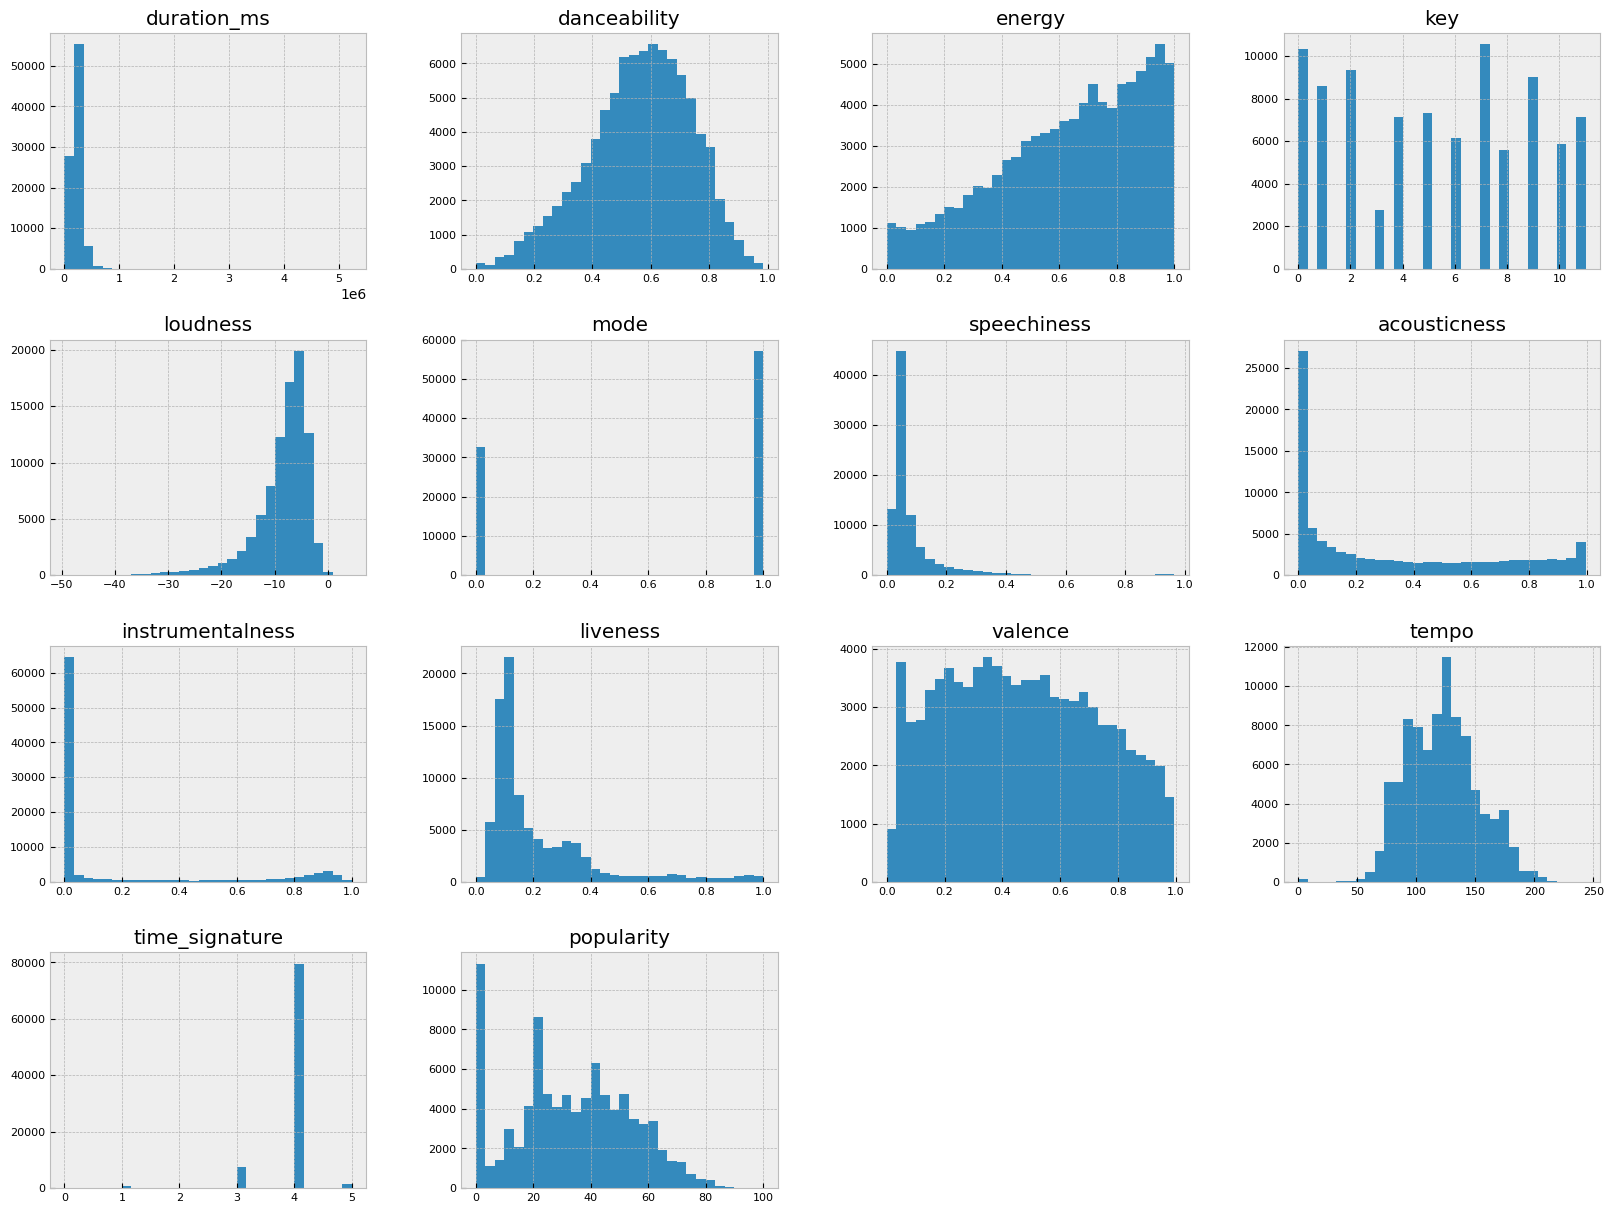

In [16]:
numerical_cols.hist(figsize=(20,15), bins=30, xlabelsize=8, ylabelsize=8)
plt.savefig('../images/histograma_columnas_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

- Se puede observar que danceability y tempo tienen una distribución normal.
- loudness tiene tendencia hacia la derecha.

## ¿Existen inconsistencias?

Revisamos si los valores respetan el rango de negocio documentado por Spotify para cada variable de audio (por ejemplo, que danceability esté entre 0 y 1, o que loudness no sea positivo). Esto permite detectar valores que, sin ser outliers extremos, son físicamente imposibles (ej. tempo o compás en 0).

In [17]:
# Rango válido esperado para cada columna numérica, según la documentación de Spotify.
# incluye_minimo=False marca columnas donde el propio mínimo (0) es físicamente inválido.
rangos_validos = {
    'duration_ms':      (0, np.inf, False),   # una canción no puede durar 0 ms
    'danceability':     (0, 1, True),
    'energy':           (0, 1, True),
    'key':              (0, 11, True),        # pitch class: 0=C ... 11=B
    'loudness':         (-np.inf, 0, True),   # dB relativo a 0 dBFS, el techo digital
    'mode':             (0, 1, True),         # 0=menor, 1=mayor
    'speechiness':      (0, 1, True),
    'acousticness':     (0, 1, True),
    'instrumentalness': (0, 1, True),
    'liveness':         (0, 1, True),
    'valence':          (0, 1, True),
    'tempo':            (0, np.inf, False),   # una canción no puede tener 0 BPM
    'time_signature':   (3, 7, True),         # Spotify solo documenta compases de 3/4 a 7/4
    'popularity':       (0, 100, True),
}

filas_resumen = []
for columna, (minimo, maximo, incluye_minimo) in rangos_validos.items():
    serie = numerical_cols[columna]
    bajo_minimo = (serie < minimo).sum() if incluye_minimo else (serie <= minimo).sum()
    sobre_maximo = (serie > maximo).sum()
    filas_resumen.append({
        'columna': columna,
        'rango_valido': f'{"[" if incluye_minimo else "("}{minimo}, {maximo}]',
        'bajo_minimo': bajo_minimo,
        'sobre_maximo': sobre_maximo,
        'total_inconsistentes': bajo_minimo + sobre_maximo,
    })

resumen_inconsistencias = pd.DataFrame(filas_resumen).sort_values('total_inconsistentes', ascending=False)
resumen_inconsistencias

,columna,rango_valido,bajo_minimo,sobre_maximo,total_inconsistentes
12,time_signature,"[3, 7]",1008,0,1008
11,tempo,"(0, inf]",157,0,157
4,loudness,"[-inf, 0]",0,68,68
0,duration_ms,"(0, inf]",0,0,0
1,danceability,"[0, 1]",0,0,0
2,energy,"[0, 1]",0,0,0
3,key,"[0, 11]",0,0,0
5,mode,"[0, 1]",0,0,0
6,speechiness,"[0, 1]",0,0,0
7,acousticness,"[0, 1]",0,0,0


La tabla anterior solo marca lo que se sale del rango documentado por Spotify, pero eso no prueba que sea un dato inconsistente: se analiza cada caso por separado antes de asumirlo. Se separan los dos valores de time_signature fuera de rango (0 y 1) y se dejan los cálculos listos; los resultados se resumen en la tabla markdown de abajo.

In [18]:
cruce_ts0_tempo0 = pd.crosstab(df2['time_signature'] == 0, df2['tempo'] == 0,
                                rownames=['time_signature==0'], colnames=['tempo==0'])

resumen_tempo_por_ts = pd.DataFrame([
    {
        'time_signature': etiqueta,
        'tempo_medio_bpm': grupo['tempo'].mean(),
        'pct_tempo_cero': (grupo['tempo'] == 0).mean() * 100,
    }
    for etiqueta, grupo in [
        ('0', df2[df2['time_signature'] == 0]),
        ('1', df2[df2['time_signature'] == 1]),
        ('3 a 7', df2[df2['time_signature'] >= 3]),
    ]
])

generos_ts0 = df2.loc[df2['time_signature'] == 0, 'track_genre'].value_counts().head(5)
generos_ts1 = df2.loc[df2['time_signature'] == 1, 'track_genre'].value_counts().head(5)

- danceability, energy, speechiness, acousticness, instrumentalness, liveness, valence, key, mode y popularity: sin inconsistencias, todos los valores respetan el rango documentado por Spotify, ya que su propia API los acota entre 0 y 1 (o entre 0 y 11/100 según corresponda).
- **loudness**: 68 filas tienen loudness positivo (hasta 4.53 dB), cuando lo esperado es que sea ≤ 0 dB (0 dBFS es el techo digital de una pista). Son másters muy comprimidos/normalizados que llegan a superar ese techo; no son errores de carga, pero sí un caso atípico a tener presente, se visualiza mejor en el boxplot más abajo.
- tempo: **157 filas** con tempo = 0 BPM, lo cual no es físicamente posible.

Para time signature realizaremos un análisis más exhaustivo debido a su naturaleza.

**Cruce time_signature == 0 vs. tempo == 0** (cruce_ts0_tempo0):

| time_signature = 0 | tempo ≠ 0 | tempo = 0 |
|---|---:|---:|
| No | 89.578 | 0 |
| Sí | 5 | 157 |

**Tempo real por grupo de time_signature** (resumen_tempo_por_ts):

| time_signature | tempo medio (BPM) | % con tempo = 0 |
|---|---:|---:|
| 0 | 3.6 | 96.9% |
| 1 | 108.3 | 0.0% |
| 3 a 7 | 122.4 | 0.0% |

**Géneros más comunes con time_signature = 0** (generos_ts0):

| Género | Canciones |
|---|---:|
| sleep | 138 |
| guitar | 4 |
| iranian | 4 |
| opera | 3 |
| ambient | 3 |

**Géneros más comunes con time_signature = 1** (generos_ts1):

| Género | Canciones |
|---|---:|
| sleep | 57 |
| comedy | 56 |
| grindcore | 36 |
| ambient | 30 |
| iranian | 29 |

- time_signature: la tabla marca **1.008 filas** fuera del rango documentado (3/4 a 7/4), pero al investigar los dos valores por separado no son el mismo tipo de problema:
  - **time_signature = 0 (162 filas) sí es una inconsistencia real**: el 97% de estas filas (157 de 162) también tiene tempo = 0, es decir, es el mismo fallo del algoritmo y el 85% pertenece al género sleep (sonidos ambientales sin pulso musical detectable). Spotify no logra estimar ni tempo ni compás y devuelve 0 en ambos, no un compás real.
  - **time_signature = 1 (846 filas) NO es una inconsistencia**: ninguna de estas filas tiene tempo = 0 (todas tienen un tempo real y coherente, ~108 BPM en promedio) y sus géneros son muy variados (comedy, grindcore, ambient, classical, opera, etc.), es decir, pistas sin un pulso regular claro (voz hablada, rubato, cambios de compás constantes). Un compás de "1/4" es inusual pero musicalmente válido, y aquí el algoritmo sí entrega una estimación coherente con el resto de sus features, solo es un caso extremo, no un dato roto.

En conjunto con la fila de duration_ms = 0 ya eliminada, los casos confirmados como inválidos (tempo = 0 y time_signature = 0, que en la práctica son casi las mismas 157-162 filas) quedan pendientes para la etapa de tratamiento de datos faltantes/inválidos. time_signature = 1 se conserva tal cual, ya que sí representa información real.

## ¿Existen Outliers?

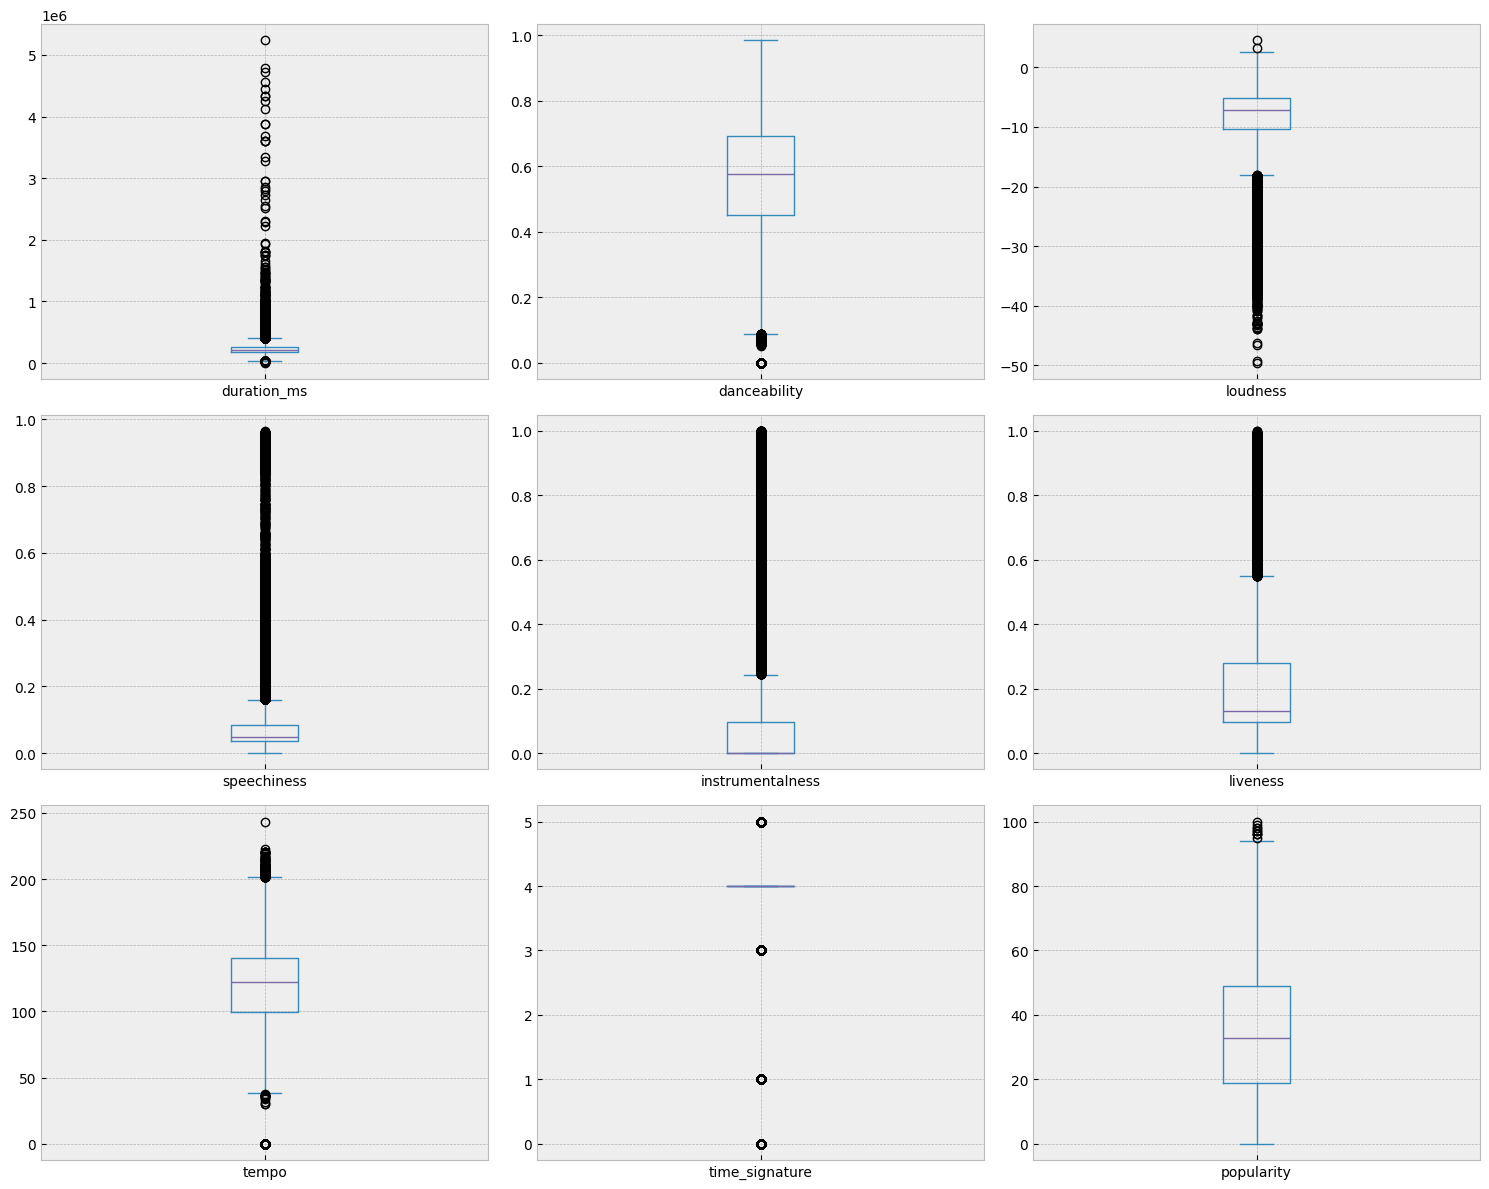

In [19]:
cols_a_excluir = ['energy', 'valence', 'acousticness', 'key', 'mode']
numerical_cols.drop(columns=cols_a_excluir).plot(kind='box', subplots=True, layout=(3,3), figsize=(15,12), sharex=False, sharey=False)
plt.tight_layout()
plt.savefig('../images/boxplot_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

- duration_ms: bastantes outliers hacia arriba (canciones de varias horas de duración) y hacia abajo (fragmentos de hasta 8,6 segundos, que en esta escala se ven pegados a cero pero no lo son).
- loudness: numerosos outliers hacia abajo (canciones muy silenciosas, hasta -49 dB).
- speechiness, instrumentalness y liveness: gran cantidad de outliers hacia arriba, esperable, ya que la mayoría de las canciones tiene un valor cercano a 0 y solo unas pocas (habladas, instrumentales o en vivo) se alejan del resto.
- tempo y time_signature: además de outliers normales en los extremos, hay un grupo de valores en 0 que no tiene sentido físico (ninguna canción tiene 0 BPM o compás 0). Se cuentan 157 filas con tempo = 0.
- popularity: algunos outliers hacia arriba (canciones muy populares), sin mayor problema.

## Correlación entre variables

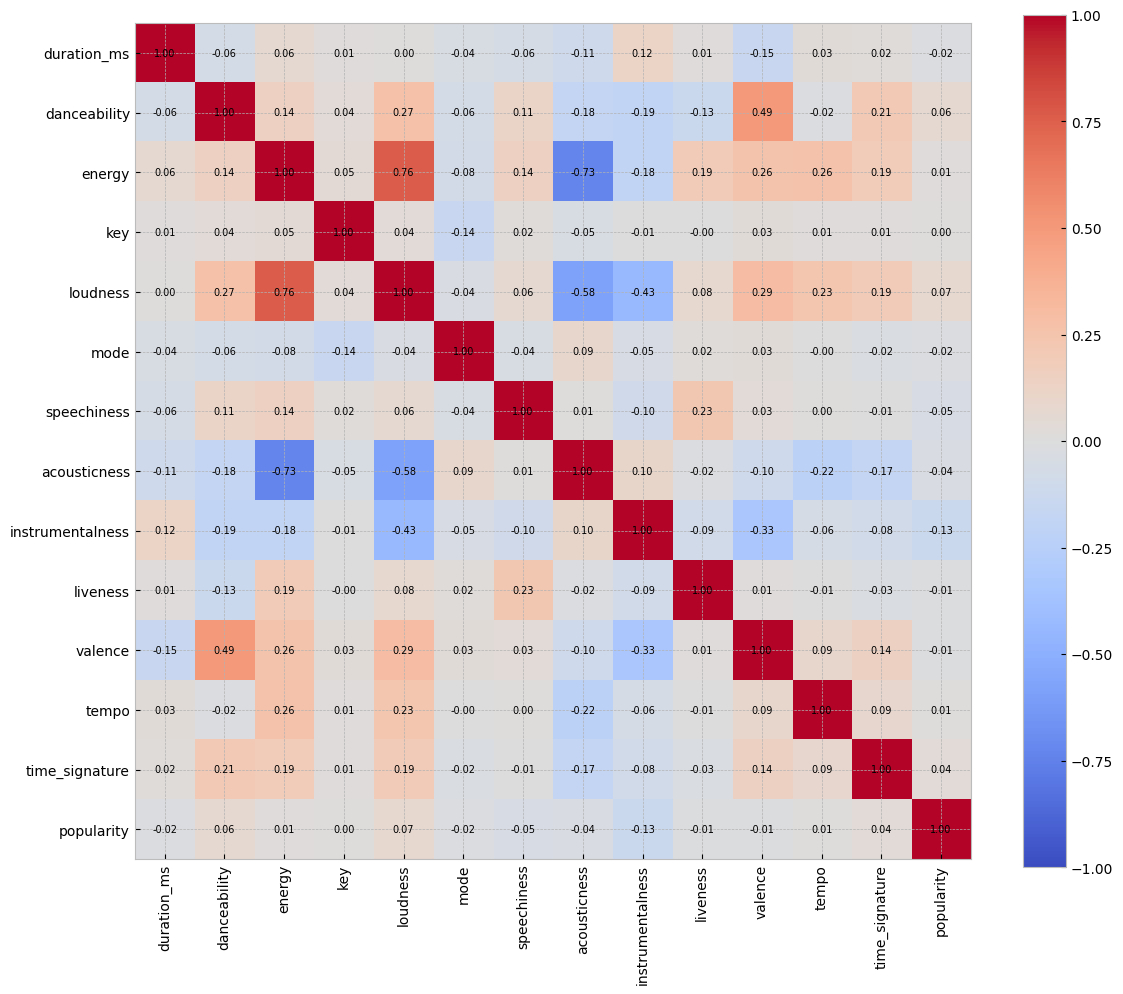

In [20]:
correlacion = numerical_cols.corr()

fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.imshow(correlacion, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlacion.columns)))
ax.set_yticks(range(len(correlacion.columns)))
ax.set_xticklabels(correlacion.columns, rotation=90)
ax.set_yticklabels(correlacion.columns)
fig.colorbar(cax)

for i in range(len(correlacion.columns)):
    for j in range(len(correlacion.columns)):
        ax.text(j, i, f'{correlacion.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('../images/matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

- energy y loudness tienen una correlación fuerte y positiva (0.76): canciones más "energéticas" suenan más fuerte.
- acousticness se correlaciona fuerte y negativamente con energy (-0.73) y con loudness (-0.58): las canciones acústicas tienden a ser menos intensas y más silenciosas, como es esperable.
- instrumentalness también se correlaciona negativamente con loudness (-0.43) y con valence (-0.33).
- Ninguna variable tiene una correlación fuerte con popularity (el target): la más alta es instrumentalness con apenas -0.13, seguida de loudness (0.07) y danceability (0.06), el resto es prácticamente 0. Esto sugiere que la popularidad no se explica linealmente por los atributos de audio, algo a tener en cuenta para la etapa de modelado.

## Datos categóricos

In [21]:
categorical_cols = df2[df2.columns[(df2.dtypes == 'object') | (df2.dtypes == 'bool')]]
categorical_cols.sample(5)

,track_id,artists,album_name,track_name,explicit,track_genre
48969,4FyflphvUqX71jrNDqTg4J,Witchery,In His Infernal Majesty's Service,Feed the Gun,False,black-metal
68664,5y0nMZC5kF6uLYaLc97mSo,DJ Snake;J Balvin;Tyga,Fiesta portatil,Loco Contigo,False,dance;edm;electro;electronic
31582,2k40QBxYjAf1aadR3tG33L,LOCKBOX;Dani King,Disarm You,Disarm You,False,dub;dubstep
73588,6ONiXjA3qViG5bg68hjiLm,2 Brothers On The 4th Floor,I'm Thinkin' Of U,Living In XTC,False,happy
80238,6xqWfkMmiqbepWSXMj19K1,Aretha Franklin,Thanksgiving Party,This Girl's in Love with You,False,blues;jazz;soul


In [22]:
categorical_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89740 entries, 0 to 89739
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   track_id     89740 non-null  object
 1   artists      89740 non-null  object
 2   album_name   89740 non-null  object
 3   track_name   89740 non-null  object
 4   explicit     89740 non-null  bool  
 5   track_genre  89740 non-null  object
dtypes: bool(1), object(5)
memory usage: 3.5+ MB


In [23]:
df1.describe(include=['object', 'bool'])

,track_id,artists,album_name,track_name,explicit,track_genre
count,114000,113999,113999,113999,114000,114000
unique,89741,31437,46589,73608,2,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,False,acoustic
freq,9,279,195,151,104253,1000


In [24]:
categorical_cols.describe()

,track_id,artists,album_name,track_name,explicit,track_genre
count,89740,89740,89740,89740,89740,89740
unique,89740,31437,46589,73608,2,1432
top,0000vdREvCVMxbQTkS888c,George Jones,The Complete Hank Williams,Rockin' Around The Christmas Tree,False,tango
freq,1,260,110,48,82036,999


describe() no separa por ';', trata cada combinación de géneros como una categoría distinta. Para contar canciones por género real hay que "explotar" la columna primero. Por lo tanto si en algún momento queremos trabajar el género, hay que realizar esto.

Ojo, si se quiere realizar análisis de los artistas es lo mismo, ya que hay artista que se separan por ;.

### Sobre los géneros por canción

Como se señaló antes, track_genre es multi-etiqueta (géneros separados por ;), así que describe()/value_counts() sobre la columna tal cual tratan cada combinación de géneros como una categoría distinta (1.432 combinaciones). Para analizar los géneros reales hay que "explotar" la columna: una fila por cada (canción, género) individual.

Géneros únicos: 114


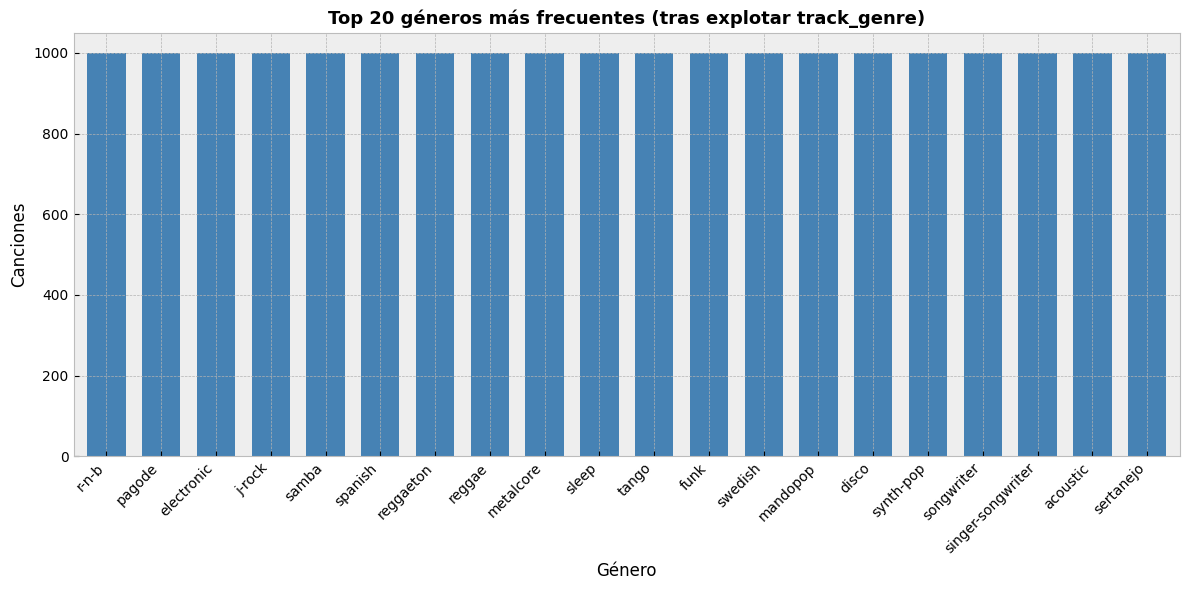

In [25]:
generos_explotados = df2['track_genre'].str.split(';').explode()
conteo_generos = generos_explotados.value_counts()

print(f'Géneros únicos: {conteo_generos.size}')

conteo_generos.head(20).plot(
    kind='bar', figsize=(12, 6), color='steelblue', width=0.7
)
plt.title('Top 20 géneros más frecuentes (tras explotar track_genre)', fontsize=13, fontweight='bold')
plt.ylabel('Canciones')
plt.xlabel('Género')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../images/top_20_generos.png', dpi=150, bbox_inches='tight')
plt.show()

Hay **114 géneros únicos**, y el gráfico llama la atención por lo parejo que se ve: los 15 primeros están todos exactamente en 1.000 canciones. Al revisar los 114 géneros completos (`conteo_generos.describe()`), el patrón se confirma: media 996, mínimo 904, máximo 1.000, con la mayoría muy cerca de 1.000. Esto no es una distribución orgánica de géneros musicales, es la huella del diseño del dataset: Los géneros con menos de 1.000 (ej. romance con 904, classical con 933) simplemente perdieron algunas canciones al eliminar los 450 duplicados exactos vistos al principio.

**Implicancia para el modelado:** track_genre no refleja qué tan popular es un género en Spotify en la vida real, es una muestra balanceada por diseño. Si se usa como predictor, hay que tenerlo presente al interpretar resultados (y es un punto relevante para la sección de sesgos del informe).

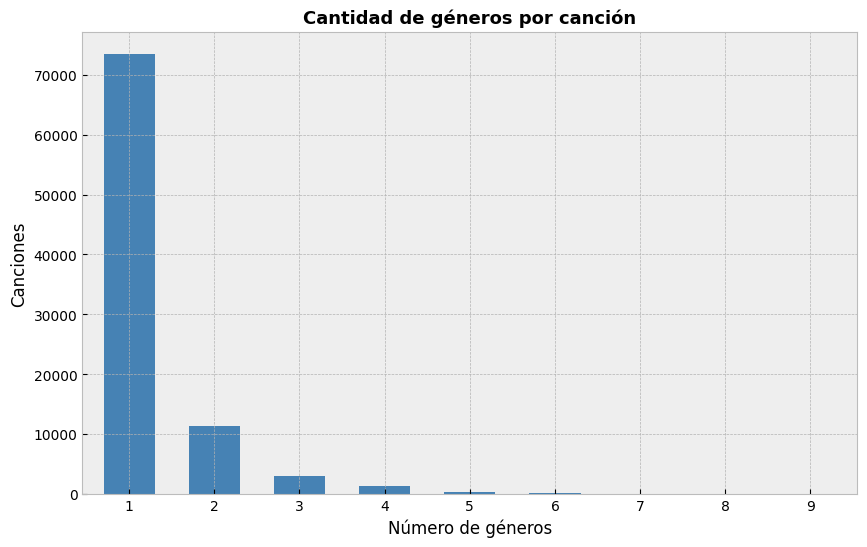

In [26]:
n_generos_por_cancion = df2['track_genre'].str.split(';').apply(len)

n_generos_por_cancion.value_counts().sort_index().plot(
    kind='bar', figsize=(10, 6), color='steelblue', width=0.6
)
plt.title('Cantidad de géneros por canción', fontsize=13, fontweight='bold')
plt.xlabel('Número de géneros')
plt.ylabel('Canciones')
plt.xticks(rotation=0)
plt.savefig('../images/generos_por_cancion.png', dpi=150, bbox_inches='tight')
plt.show()

La mayoría de las canciones tiene*un solo género (73.441 de 89.740, ~82%), pero hay una cola larga: 11.424 tienen 2 géneros, 2.955 tienen 3, y así hasta un caso extremo con 9 géneros distintos. El promedio es 1.27 géneros por canción y la mediana es 1, coherente con que la mayoría de las 24.259 filas duplicadas por track_id detectadas al principio se repetían en solo 2 géneros, no en muchos.

## Distribución de popularity

popularity es el target, pero hasta ahora solo se vio junto al resto de las variables numéricas (histograma general y `describe()`). Por lo que se analiza en mayor profundidad ahora.

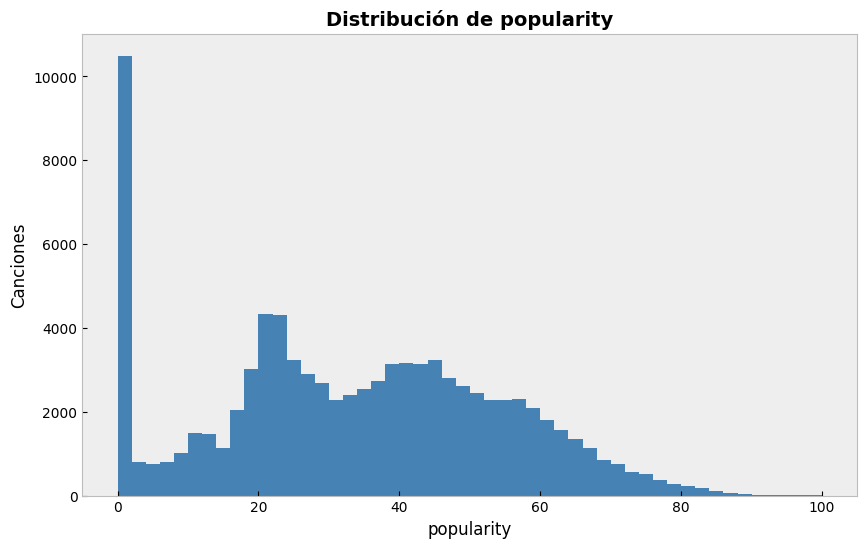

In [27]:
df2['popularity'].hist(bins=50, figsize=(10, 6), color='steelblue', grid=False)
plt.title('Distribución de popularity', fontsize=14, fontweight='bold')
plt.xlabel('popularity')
plt.ylabel('Canciones')
plt.savefig('../images/distribucion_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

Aparte del pico en 0, el resto de la distribución es razonablemente simétrica. Pero ese pico es real y grande: **9.413 canciones (10.49%) tienen popularity = 0 exacto**, muchas más de las que se esperarían en una distribución continua suave. Esto es consistente con lo visto en la sección de géneros: buena parte del dataset es música de catálogo/producción (ambient, sleep, stock) que en Spotify prácticamente no se reproduce.

Ese pico tampoco es enteramente atribuible al género: el 54% de estas filas con popularity = 0 (5.088 de 9.413) pertenecen a los grupos de audio duplicado vistos antes (sección "¿Existen filas duplicadas?"), y en 779 de esos grupos la misma canción tiene popularity = 0 en un release y > 0 en otro. Buena parte del pico en 0 no es "esta canción no se reproduce", sino "este release específico no se reproduce" — el mismo efecto de contexto de publicación detectado más arriba.

## Variables candidatas para la etapa de preparación de datos

Además de las columnas originales ya revisadas, se probaron algunas transformaciones e
interacciones entre variables de audio para ver si captan algo que las columnas por sí solas no
muestran. Esto no es parte del tratamiento de datos en sí (eso corresponde a
[`preprocesamiento.ipynb`](preprocesamiento.ipynb)), sino una exploración adicional para decidir
qué vale la pena llevar a esa etapa.

### Interacciones entre variables de audio

In [28]:
interacciones = {
    'valence*energy (euforia)': df2['valence'] * df2['energy'],
    'danceability*energy': df2['danceability'] * df2['energy'],
    'acousticness*instrumentalness': df2['acousticness'] * df2['instrumentalness'],
    'loudness*energy': df2['loudness'] * df2['energy'],
    'danceability*valence': df2['danceability'] * df2['valence'],
    'danceability - acousticness': df2['danceability'] - df2['acousticness'],
}
for nombre, serie in interacciones.items():
    print(f'{nombre:32s} r = {serie.corr(df2["popularity"]):+.4f}')

valence*energy (euforia)         r = +0.0022
danceability*energy              r = +0.0381
acousticness*instrumentalness    r = -0.0485
loudness*energy                  r = +0.0588
danceability*valence             r = -0.0017
danceability - acousticness      r = +0.0600


Ninguna interacción supera |r| = 0.06 con popularity, del mismo orden que las variables de
audio originales (máximo 0.13, visto en la matriz de correlación más arriba). No se consideran
candidatas para la preparación de datos.

### ¿Existe una duración óptima?

In [29]:
df2['dur_min'] = df2['duration_ms'] / 60000
bins = [0, 2, 2.5, 3, 3.5, 4, 4.5, 5, 6, 100]
df2['dur_bin'] = pd.cut(df2['dur_min'], bins=bins)

print('Popularidad media por rango de duración:')
print(df2.groupby('dur_bin', observed=True)['popularity'].agg(['count', 'mean']).round(2))

r_bruto = df2['duration_ms'].corr(df2['popularity'])
r_distancia = (df2['dur_min'] - 3.75).abs().corr(df2['popularity'])
print(f'\nr(duration_ms, popularity)              = {r_bruto:+.4f}')
print(f'r(|duración - 3.75 min|, popularity)     = {r_distancia:+.4f}')

Popularidad media por rango de duración:
              count   mean
dur_bin                   
(0.0, 2.0]     5557  27.95
(2.0, 2.5]     7275  31.75
(2.5, 3.0]    13243  33.07
(3.0, 3.5]    16833  34.40
(3.5, 4.0]    15342  35.54
(4.0, 4.5]    10879  34.93
(4.5, 5.0]     7045  34.51
(5.0, 6.0]     7010  32.25
(6.0, 100.0]   6556  27.71

r(duration_ms, popularity)              = -0.0232
r(|duración - 3.75 min|, popularity)     = -0.0857


La popularidad promedio sube y baja en forma de U invertida según la duración: mínima en
canciones muy cortas (< 2 min, 27.95) y muy largas (> 6 min, 27.71), máxima entre 3.5 y 4 minutos
(35.54), el rango de duración típico de una canción de radio/streaming. Como duration_ms es
una relación lineal, esta forma de U no se puede capturar directamente con esa columna: la
correlación lineal es casi nula (r ≈ -0.02), pero al medir la **distancia a 3.75 minutos** en vez
del valor bruto, la correlación sube a r ≈ -0.09, más fuerte que la mayoría de las variables de
audio originales.

**Candidata para la preparación de datos:** distancia_duracion_optima =
|duración_en_minutos − 3.75|.

## Cuadrantes de ánimo (valence x energy)

In [30]:
def cuadrante(fila):
    if fila['valence'] >= 0.5 and fila['energy'] >= 0.5:
        return 'eufórico (alegre+intenso)'
    if fila['valence'] >= 0.5 and fila['energy'] < 0.5:
        return 'calmado positivo'
    if fila['valence'] < 0.5 and fila['energy'] >= 0.5:
        return 'tenso/agresivo'
    return 'melancólico'

df2['cuadrante_animo'] = df2.apply(cuadrante, axis=1)
resumen_cuadrantes = df2.groupby('cuadrante_animo')['popularity'].agg(['count', 'mean'])
resumen_cuadrantes['pct'] = (resumen_cuadrantes['count'] / len(df2) * 100).round(2)
print(resumen_cuadrantes.round(2))

                           count   mean    pct
cuadrante_animo                               
calmado positivo            7279  29.70   8.11
eufórico (alegre+intenso)  33220  33.39  37.02
melancólico                19030  32.97  21.21
tenso/agresivo             30211  33.98  33.67


In [31]:
# Regresión lineal simple (ecuaciones normales) de popularity sobre valence y energy,
# para ver si el cuadrante aporta algo que esas dos variables no expliquen por separado.
y = df2['popularity'].astype(float).to_numpy()
A = np.column_stack([np.ones(len(df2)), df2['valence'].to_numpy(), df2['energy'].to_numpy()])
coef = np.linalg.solve(A.T @ A, A.T @ y)

pred_lineal = coef[0] + coef[1] * df2['valence'] + coef[2] * df2['energy']
df2['residuo_lineal'] = df2['popularity'] - pred_lineal

print(f'popularity ≈ {coef[0]:.2f} + ({coef[1]:.2f})*valence + ({coef[2]:.2f})*energy')
print()
print('Residuo promedio por cuadrante (si el cuadrante aporta algo extra, debería alejarse de 0):')
print(df2.groupby('cuadrante_animo')['residuo_lineal'].agg(['count', 'mean']).round(3))

popularity ≈ 32.89 + (-1.26)*valence + (1.43)*energy

Residuo promedio por cuadrante (si el cuadrante aporta algo extra, debería alejarse de 0):
                           count   mean
cuadrante_animo                        
calmado positivo            7279 -2.840
eufórico (alegre+intenso)  33220  0.324
melancólico                19030 -0.021
tenso/agresivo             30211  0.341


Tres de los cuatro cuadrantes quedan bien explicados por la combinación lineal de valence y
energy (residuo promedio ≈ 0). El cuadrante **calmado positivo** (valence alto, energy
bajo. Baladas acústicas, chill) es la excepción: su popularidad real queda en promedio 2.84
puntos por debajo de lo que predicen valence y energy por separado, sobre 7.279 canciones
(8.1% del dataset). Es una señal que esas dos columnas no capturan por sí solas.

**Candidata para la preparación de datos:** es_calmado_positivo = bandera binaria para
valence >= 0.5 y energy < 0.5.

---

Ambas quedan documentadas aquí como candidatas surgidas del análisis exploratorio; su
incorporación efectiva al flujo de preparación se decide y se justifica en
[`preprocesamiento.ipynb`](preprocesamiento.ipynb).